In [25]:
# load netcdf from OM4 runs

import numpy as np
import matplotlib.pyplot as plt
import os
import xarray as xr
import xgcm 
import cartopy.crs as ccrs
from matplotlib.colorbar import ColorbarBase

In [26]:
!pip install xgcm

Defaulting to user installation because normal site-packages is not writeable


In [27]:
!pip install xoverturning

Defaulting to user installation because normal site-packages is not writeable


In [28]:
!pip install regionmask

Defaulting to user installation because normal site-packages is not writeable


In [29]:
# paths to dataset
BASE = '/orcd/data/abodner/001/om4_output/new_runs/'

# load FK data for MOC calculation

ds_ann_FK = xr.open_mfdataset(BASE+'BFF11/ocean_annual_z.*.ann-*.nc')
ds_moc_FK = xr.merge([ds_ann_FK.umo, ds_ann_FK.vmo, ds_ann_FK.uhml, ds_ann_FK.vhml])

# load FK data for MOC calculation

ds_ann_BD = xr.open_mfdataset(BASE+'BOD23/ocean_annual_z.*.ann-*.nc') 
ds_moc_BD = xr.merge([ds_ann_BD.umo, ds_ann_BD.vmo, ds_ann_BD.uhml, ds_ann_BD.vhml])

# load static file
ds_stat = xr.open_dataset(BASE+'ocean_annual_z.static.nc')
    

In [30]:
ds_stat

<xarray.Dataset> Size: 162MB
Dimensions:       (yq: 1081, xq: 1441, yh: 1080, xh: 1440)
Coordinates:
  * xh            (xh) float64 12kB -299.7 -299.5 -299.2 ... 59.53 59.78 60.03
  * xq            (xq) float64 12kB -299.6 -299.3 -299.1 ... 59.91 60.16 60.16
  * yh            (yh) float64 9kB -80.39 -80.31 -80.23 ... 89.73 89.84 89.95
  * yq            (yq) float64 9kB -80.35 -80.27 -80.19 ... 89.89 90.0 90.0
Data variables: (12/26)
    Coriolis      (yq, xq) float32 6MB ...
    areacello     (yh, xh) float32 6MB ...
    areacello_bu  (yq, xq) float32 6MB ...
    areacello_cu  (yh, xq) float32 6MB ...
    areacello_cv  (yq, xh) float32 6MB ...
    deptho        (yh, xh) float32 6MB ...
    ...            ...
    hfgeou        (yh, xh) float32 6MB ...
    sftof         (yh, xh) float32 6MB ...
    wet           (yh, xh) float32 6MB ...
    wet_c         (yq, xq) float32 6MB ...
    wet_u         (yh, xq) float32 6MB ...
    wet_v         (yq, xh) float32 6MB ...
Attributes:
    external_variables:  areacello areacello

In [31]:
from xoverturning import calcmoc

In [34]:
# calculate global MOC
amoc_FK = calcmoc(ds_moc_FK, dsgrid=ds_stat ,basin='atl-arc')
amoc_BD = calcmoc(ds_moc_BD, dsgrid=ds_stat ,basin='atl-arc')

generating basin codes


/orcd/home/001/abodner/.local/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


generating basin codes


/orcd/home/001/abodner/.local/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


In [35]:
### BLOM ###
# path to dataset
PATH_BLOM = '/orcd/data/abodner/001/blom_output/'
# AMOC is in kg/s so we need to multiply with 1e-9 to convert to Sv

# load BFF11 data 
BLOM_AMOC_BFF11 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner01_amoc.nc')*1e-9

# load BOD23 data tuned
BLOM_AMOC_BOD23 = xr.open_dataset(PATH_BLOM+'N2NOIIAJRA20TR_TL319_tn14_Bodner03_amoc.nc')*1e-9  

#load grid
BLOM_grid = xr.open_dataset(PATH_BLOM+'grid_tnx1v4_20170622.nc')  



In [36]:
### CESM ###
# path to dataset
PATH_CESM = '/orcd/data/abodner/001/cesm_output/'
# load BFF11 data 
CESM_AMOC_BFF11 = xr.open_dataset(PATH_CESM+'051_BFF11_Lf_1km/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.051_MOC.nc').isel(time=slice(45,65)).mean("time")

# load BFF11 legacy simulation
#CESM_AMOC_BFF11_Li16 = xr.open_dataset(PATH_CESM+'045_BFF11_Li16/ncfiles/g.e30_b05.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.045_MOC.nc').isel(time=slice(45,65)).mean("time")

# load BOD23 data tuned 
CESM_AMOC_BOD23 = xr.open_dataset(PATH_CESM+'049_BOD23_Cr_v8/ncfiles/g.e30_a06a.GJRAv4.TL319_t232_wgx3_hycom1_N75.2025.049_MOC.nc').isel(time=slice(45,65)).mean("time")



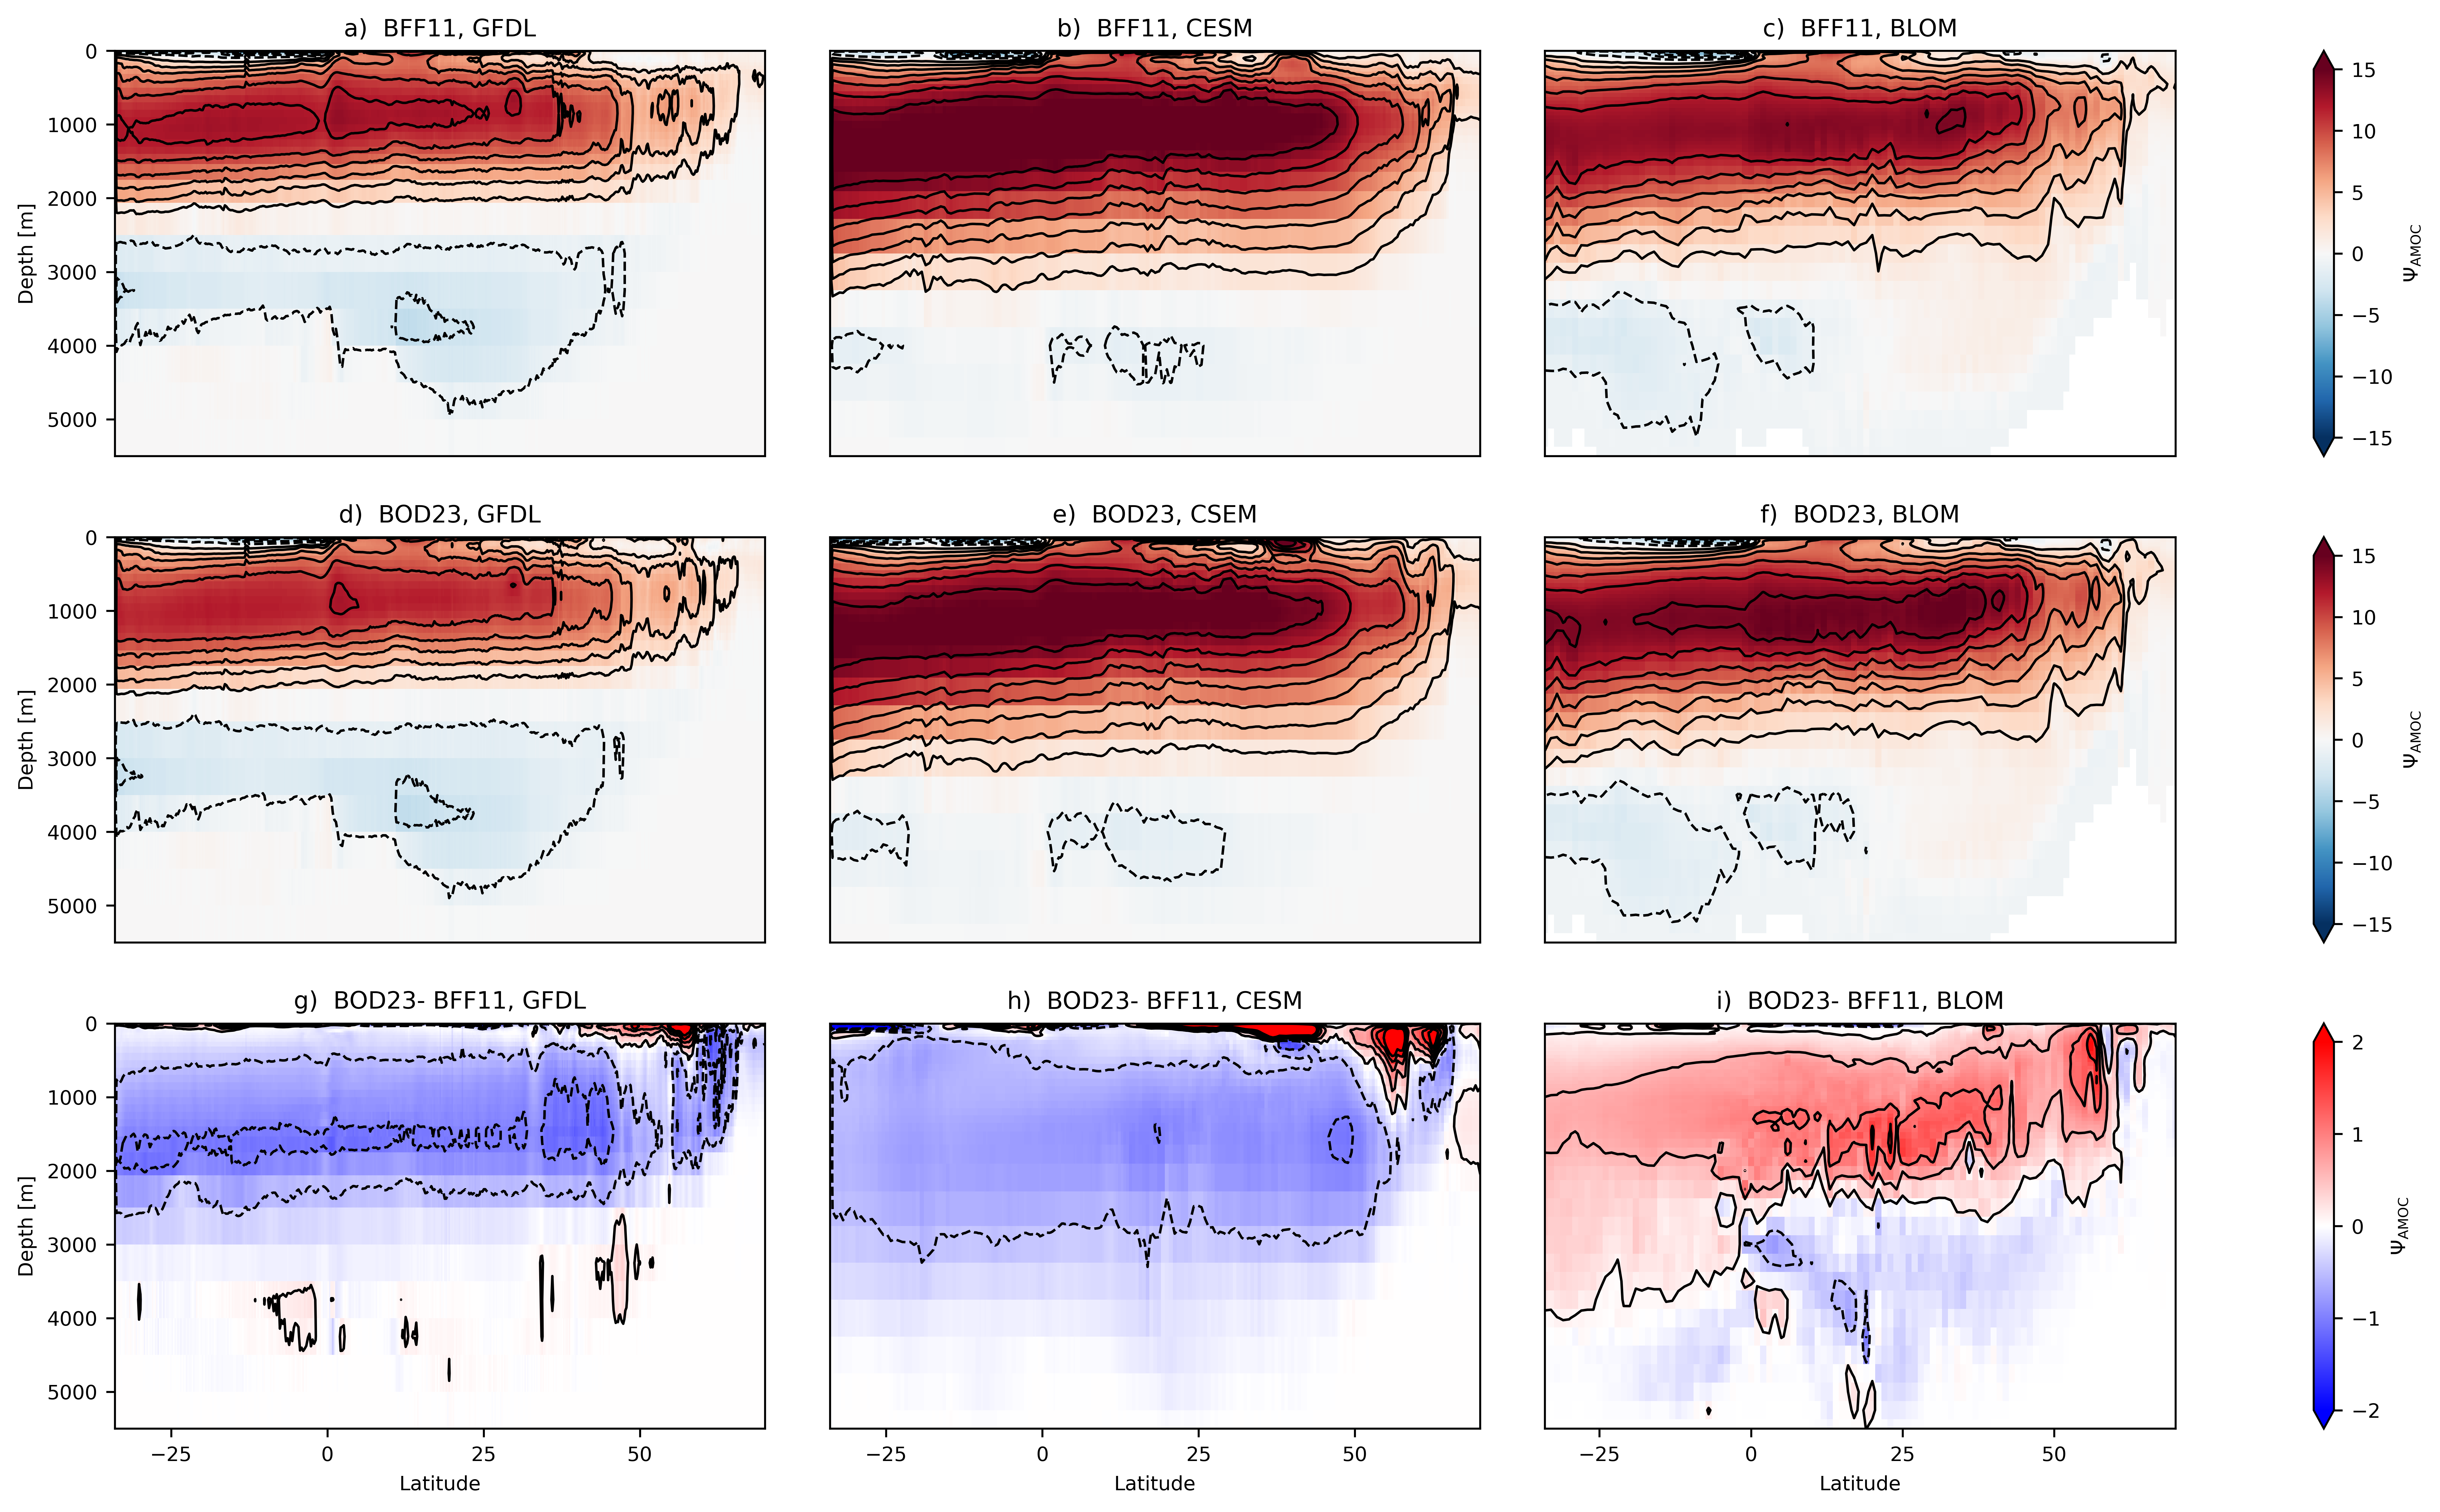

In [54]:
# make plots of  20 year average
fig, ax = plt.subplots(nrows=3,ncols=3, figsize=(15,10), dpi=600)

ax=ax.flatten()


i_ax = 0
amoc_FK.mean('time').rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-15,vmax=15,cmap='RdBu_r',add_colorbar=False)
amoc_FK.mean('time').rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-15,0,2),np.arange(2,15,2)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('a)  BFF11, GFDL')
ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('')
ax[i_ax].set_xticks([])

i_ax = 3
amoc_BD.mean('time').rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-15,vmax=15,cmap='RdBu_r',add_colorbar=False)
amoc_BD.mean('time').rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-15,0,2),np.arange(2,15,2)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('d)  BOD23, GFDL')
ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('')
ax[i_ax].set_xticks([])



i_ax = 6
(amoc_BD - amoc_FK).mean('time').rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-2,vmax=2,cmap='bwr',add_colorbar=False)
(amoc_BD - amoc_FK).mean('time').rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-2,0,.5),np.arange(.1,2.5,.5)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('g)  BOD23- BFF11, GFDL')
ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('Latitude')
ax[i_ax].set_xticks([-25,0,25,50])


### CESM

i_ax = 1
CESM_AMOC_BFF11.amoc.rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-15,vmax=15,cmap='RdBu_r',add_colorbar=False)
CESM_AMOC_BFF11.amoc.rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-15,0,2),np.arange(2,15,2)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('b)  BFF11, CESM')
ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('')
ax[i_ax].set_xticks([])
ax[i_ax].set_ylabel('')
ax[i_ax].set_yticks([])

i_ax = 4
CESM_AMOC_BOD23.amoc.rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-15,vmax=15,cmap='RdBu_r',add_colorbar=False)
CESM_AMOC_BOD23.amoc.rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-15,0,2),np.arange(2,15,2)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('e)  BOD23, CSEM')
#ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('')
ax[i_ax].set_xticks([])
ax[i_ax].set_ylabel('')
ax[i_ax].set_yticks([])


i_ax = 7
(CESM_AMOC_BOD23.amoc-CESM_AMOC_BFF11.amoc).rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-2,vmax=2,cmap='bwr',add_colorbar=False)
(CESM_AMOC_BOD23.amoc-CESM_AMOC_BFF11.amoc).rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-2,0,.5),np.arange(.1,2.5,.5)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('h)  BOD23- BFF11, CESM')
#ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('Latitude')
ax[i_ax].set_ylabel('')
ax[i_ax].set_yticks([])
ax[i_ax].set_xticks([-25,0,25,50])




### BLOM
i_ax = 2
amoc= BLOM_AMOC_BFF11.amoc.rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-15,vmax=15,cmap='RdBu_r',cbar_kwargs={'ticks': np.arange(-15,20,5), 'anchor':(2.8, .5), 'pad':-.12},extend='both')
BLOM_AMOC_BFF11.amoc.rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-15,0,2),np.arange(2,15,2)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('c)  BFF11, BLOM')
ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('')
ax[i_ax].set_xticks([])
ax[i_ax].set_ylabel('')
ax[i_ax].set_yticks([])
box = ax[i_ax].get_position()


i_ax = 5
BLOM_AMOC_BOD23.amoc.rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-15,vmax=15,cmap='RdBu_r',cbar_kwargs={'ticks': np.arange(-15,20,5), 'anchor':(2.8, .5), 'pad':-.12},extend='both')
BLOM_AMOC_BOD23.amoc.rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-15,0,2),np.arange(2,15,2)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('f)  BOD23, BLOM')
#ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('')
ax[i_ax].set_xticks([])
ax[i_ax].set_ylabel('')
ax[i_ax].set_yticks([])


i_ax = 8
(BLOM_AMOC_BOD23.amoc-BLOM_AMOC_BFF11.amoc).rename('$\Psi_{\mathrm{AMOC}}$').plot(ax=ax[i_ax],vmin=-2,vmax=2,cmap='bwr',cbar_kwargs={'ticks': np.arange(-2,2.1,1), 'anchor':(2.8, .5), 'pad':-.12},extend='both')
(BLOM_AMOC_BOD23.amoc-BLOM_AMOC_BFF11.amoc).rename('$\Psi_{\mathrm{AMOC}}$').plot.contour(ax=ax[i_ax], levels=np.concatenate([np.arange(-2,0,.5),np.arange(.1,2.5,.5)]),
                      colors='k', linewidths=1)
ax[i_ax].set_ylim([5500,0])
ax[i_ax].set_xlim([-34,70])
ax[i_ax].set_title('i)  BOD23- BFF11, BLOM')
#ax[i_ax].set_ylabel('Depth [m]')
ax[i_ax].set_xlabel('Latitude')
ax[i_ax].set_ylabel('')
ax[i_ax].set_yticks([])
ax[i_ax].set_xticks([-25,0,25,50])


plt.rcParams.update({'font.size': 8})
plt.subplots_adjust(wspace=0.1, hspace=0.2)

# save figure
plt.savefig('./figures/AMOC_all_models')


## Comparing with the RAPID_MOC dataset 

In [32]:
maxmoc_265 = amoc_BD.mean('time').sel(yq=slice(25.9,26.1)).max(dim=['z_i'])

In [33]:
maxmoc_265

<xarray.DataArray 'psi' (yq: 1)>
dask.array<_nanmax_skip-aggregate, shape=(1,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * yq       (yq) float64 25.94